# RUL Prediction of Turbofan Jet Engines Using Run-to-Failure Degradation Simulations
M.L. Course A.A 2024 / 2025

Napoli Fabian 

## 1. Importing Dataset

In [223]:
train_path = "pre_processed_dataset/train.csv"
test_path = "pre_processed_dataset/test.csv"

In [224]:
import pandas as pd

df_train = pd.read_csv(train_path)
df_test = pd.read_csv(test_path)

In [225]:
df_train.drop(columns=["engine_id","cycle"], inplace=True)
df_test.drop(columns=["engine_id","cycle"], inplace=True)

## 2. Models Instance
Model selected:
- Linear regressor
- RandomForester Regressor
- KNeighbors Regressor
- Neural Network

In [226]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor


model_lr = LinearRegression()
model_dtr = RandomForestRegressor( random_state=42, n_estimators=300)
model_knn = KNeighborsRegressor(n_neighbors=17)

## 3. Measure function definition
Metrics:
- Mean-squared error ( MSE )
- Root mean-squared error ( RMSE )
- Mean absolute error ( MAE )
- Root relative squared error ( RRSE )
- Relative absolute error ( RAE )
- Correlation coefficient ( CC ).


In [227]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
from sklearn.metrics import r2_score

def calculate_errors(y_true, y_pred):
    # Mean Squared Error
    mse = mean_squared_error(y_true, y_pred)
    # Root Mean Squared Error
    rmse = np.sqrt(mse)
    # Mean Absolute Error
    mae = mean_absolute_error(y_true, y_pred)
    # Root Relative Squared Error
    rrse = np.sqrt(np.sum((y_true - y_pred) ** 2) / np.sum((y_true - np.mean(y_true)) ** 2))
    # Relative Absolute Error
    rae = np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true - np.mean(y_true)))
    # R-squared
    r2 = r2_score(y_true, y_pred)
    # Correlation Coefficient
    cc = np.corrcoef(y_true, y_pred)[0, 1]

    return {
        "MSE": mse,
        "RMSE": rmse,
        "MAE": mae,
        "RRSE": rrse,
        "RAE": rae,
        "R2": r2,
        "CC": cc
    }

## 4. Holdout method

### 4.1 Splitting and scaling data


In [228]:
X_train = df_train.drop(columns=["RUL"])
y_train = df_train["RUL"]
X_test = df_test.drop(columns=["RUL"])
y_test = df_test["RUL"]

In [229]:
#Validation Set
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.1, random_state=42)

In [230]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape, X_val.shape, y_val.shape

((18567, 13), (18567,), (100, 13), (100,), (2064, 13), (2064,))

In [231]:
#scaling data
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test= scaler.transform(X_test)

In [232]:
from sklearn.decomposition import PCA


pca = PCA (n_components=0.99)
X_train_pca = pca.fit_transform(X_train)
X_val_pca = pca.transform(X_val)
X_test_pca = pca.transform(X_test)

In [233]:
X_train_pca.shape

(18567, 13)

### 4.2 Linear Regression

In [234]:
model_lr.fit(X_train_pca, y_train)
predictions_val = model_lr.predict(X_val_pca)
predictions_test = model_lr.predict(X_test_pca)

In [235]:
errors_test = calculate_errors(y_test, predictions_test)
errors_val = calculate_errors(y_val, predictions_val)

In [236]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_actual_vs_predicted(y_true, y_pred, title="Actual vs. Predicted Values",
                             xlabel="Actual Values", ylabel="Predicted Values"):

    plt.figure(figsize=(10, 6)) # Set the figure size for better readability
    sns.scatterplot(x=y_true, y=y_pred, alpha=0.6) # Create a scatter plot

    # Add a perfect prediction line (y=x) for comparison
    all_values = np.concatenate([y_true, y_pred])
    min_val = all_values.min()
    max_val = all_values.max()
    plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Perfect Prediction')

    plt.title(title) # Set the title
    plt.xlabel(xlabel) # Set the x-axis label
    plt.ylabel(ylabel) # Set the y-axis label
    plt.grid(True, linestyle='--', alpha=0.7) # Add a grid for better readability
    plt.legend() # Show the legend for the 'Perfect Prediction' line
    plt.tight_layout() # Adjust plot to prevent labels from overlapping
    plt.show() # Display the plot

In [237]:
print("Errore Test")
for key, value in errors_test.items():
    print(f"{key}: {value}")

print("\nErrore Val")
for key, value in errors_val.items():
    print(f"{key}: {value}")

Errore Test
MSE: 470.18993410829825
RMSE: 21.68386344977062
MAE: 17.500414653238863
RRSE: 0.5218033844364773
RAE: 0.4759789881535407
R2: 0.7277212279906379
CC: 0.863074892588913

Errore Val
MSE: 687.0459609267549
RMSE: 26.211561588862935
MAE: 20.456338706465086
RRSE: 0.6273750110356534
RAE: 0.6067166657155807
R2: 0.6064005955280137
CC: 0.7794963825079138


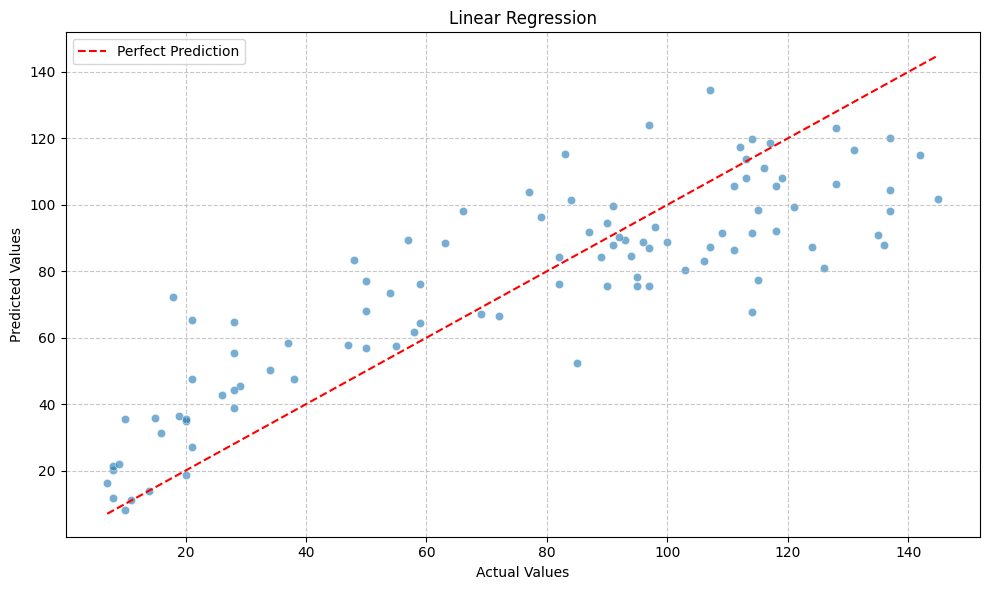

In [238]:
plot_actual_vs_predicted(y_test, predictions_test, title="Linear Regression")

### 4.3 RandomForest

In [239]:
model_dtr.fit(X_train_pca, y_train)


RandomForestRegressor(n_estimators=300, random_state=42)

In [240]:
#predictions_val = model_dtr.predict(X_val_pca)
predictions_test = model_dtr.predict(X_test_pca)

errors_test = calculate_errors(y_test, predictions_test)
#errors_val = calculate_errors(y_val, predictions_val)

print("Errore Test")
for key, value in errors_test.items():
    print(f"{key}: {value}")

print("\nErrore Val")
for key, value in errors_val.items():
    print(f"{key}: {value}")

Errore Test
MSE: 327.68508344444433
RMSE: 18.102074009473178
MAE: 13.367633333333336
RRSE: 0.43561072524474953
RAE: 0.3635749617412622
R2: 0.8102432960517434
CC: 0.9005782886837966

Errore Val
MSE: 687.0459609267549
RMSE: 26.211561588862935
MAE: 20.456338706465086
RRSE: 0.6273750110356534
RAE: 0.6067166657155807
R2: 0.6064005955280137
CC: 0.7794963825079138


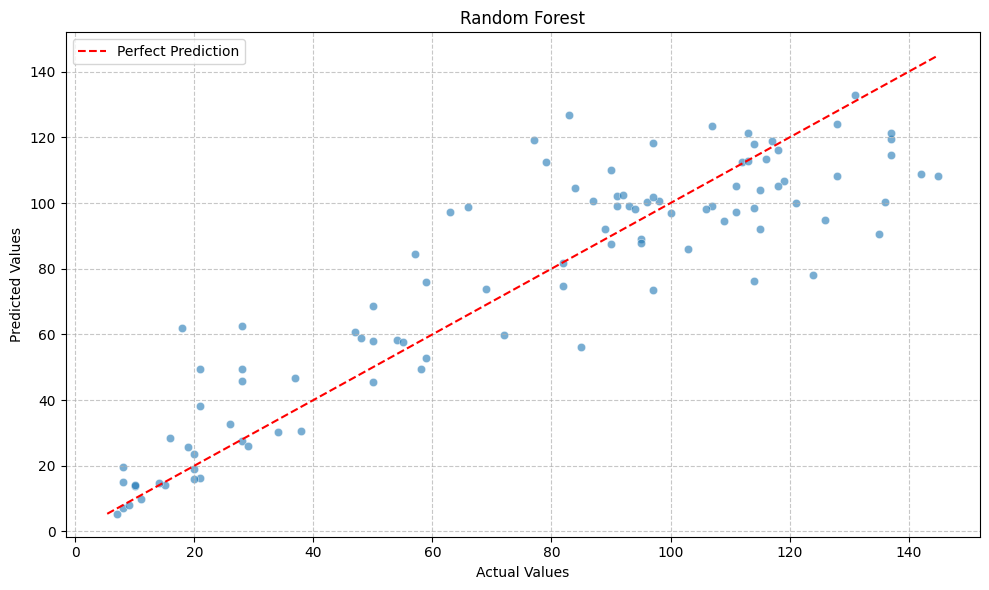

In [241]:
plot_actual_vs_predicted(y_test, predictions_test, title="Random Forest")

### 4.4 KNN

In [242]:
from sklearn.model_selection import RepeatedKFold
model_knn.fit(X_train, y_train)


KNeighborsRegressor(n_neighbors=17)

In [243]:
predictions_val = model_knn.predict(X_val)
predictions_test = model_knn.predict(X_test)

errors_test = calculate_errors(y_test, predictions_test)
errors_val = calculate_errors(y_val, predictions_val)

print("Errore Test")
for key, value in errors_test.items():
    print(f"{key}: {value}")

print("\nErrore Val")
for key, value in errors_val.items():
    print(f"{key}: {value}")

Errore Test
MSE: 352.6905882352941
RMSE: 18.780058259635247
MAE: 14.084705882352942
RRSE: 0.4519258287385846
RAE: 0.3830780119876667
R2: 0.7957630453189435
CC: 0.893706211401371

Errore Val
MSE: 647.6317946809367
RMSE: 25.448610859552563
MAE: 19.087921796625626
RRSE: 0.6091137479438683
RAE: 0.5661306470364794
R2: 0.6289804420657736
CC: 0.7955027100227873


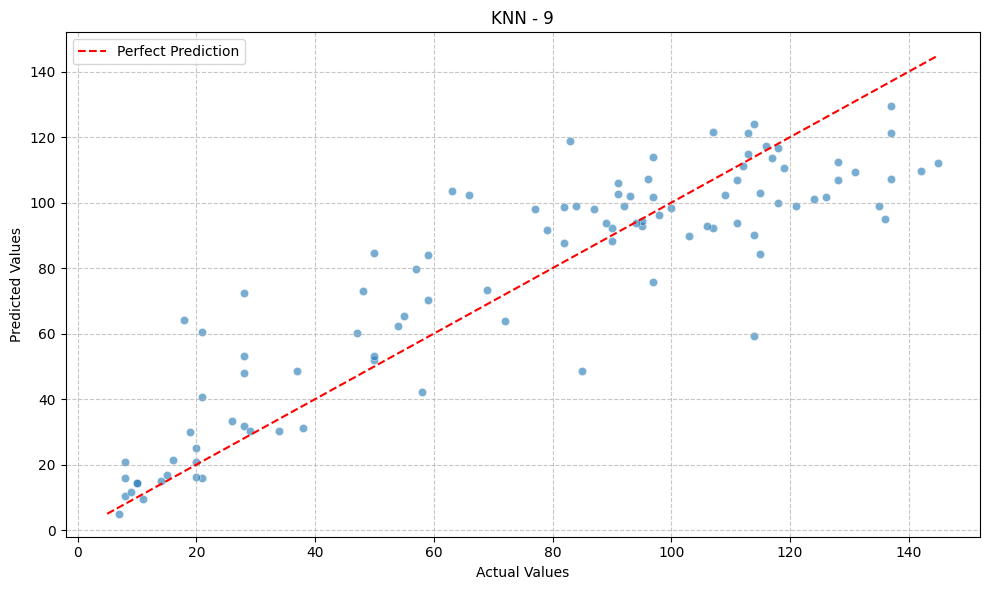

In [244]:
plot_actual_vs_predicted(y_test, predictions_test, title="KNN - 9")

### 4.5 Neural Network

In [245]:
from keras.models import Sequential
from keras.layers import Dense, Dropout, BatchNormalization
from keras.optimizers import Adam
from tensorflow.keras.optimizers import SGD

model_nn = Sequential()

model_nn.add(Dense(256, input_shape=(X_train.shape[1],), activation='relu'))
model_nn.add(BatchNormalization())
model_nn.add(Dropout(0.3))

model_nn.add(Dense(128, activation='relu'))
model_nn.add(BatchNormalization())
model_nn.add(Dropout(0.3))

model_nn.add(Dense(64, activation='relu'))
model_nn.add(BatchNormalization())
model_nn.add(Dropout(0.3))
# Output layer
model_nn.add(Dense(1, activation='linear'))

# Compilazione del modello
model_nn.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error', metrics=['mae'])

model_nn.summary()

c:\Users\thema\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_27 (Dense)                │ (None, 256)            │         3,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 46,593 (182.00 KB)

 Trainable params: 45,697 (178.50 KB)

 Non-trainable params: 896 (3.50 KB)

In [246]:
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
history = model_nn.fit(X_train_pca, y_train, epochs=200, batch_size=32, validation_data=(X_val_pca, y_val), callbacks=[early_stopping])


Epoch 1/200
581/581 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - loss: 7275.4927 - mae: 78.3546 - val_loss: 2917.4297 - val_mae: 48.0143
Epoch 2/200
581/581 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 2152.4026 - mae: 38.0252 - val_loss: 617.1280 - val_mae: 18.6635
Epoch 3/200
581/581 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 776.8543 - mae: 21.3235 - val_loss: 607.4704 - val_mae: 18.4630
Epoch 4/200
581/581 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 735.7003 - mae: 20.9624 - val_loss: 604.9951 - val_mae: 18.5853
Epoch 5/200
581/581 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 750.3481 - mae: 21.0985 - val_loss: 610.5229 - val_mae: 18.5494
Epoch 6/200
581/581 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 745.1096 - mae: 20.9488 - val_loss: 602.0978 - val_mae: 18.3483
Epoch 7/200
581/581 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 767.2014 - mae: 21.2450 - val_loss: 609.1990 - val_mae: 18.6362
Epoch 8/200
581/581 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 729.5034 - mae: 20.7772 - val_loss: 604.6095 - val_mae: 18.47

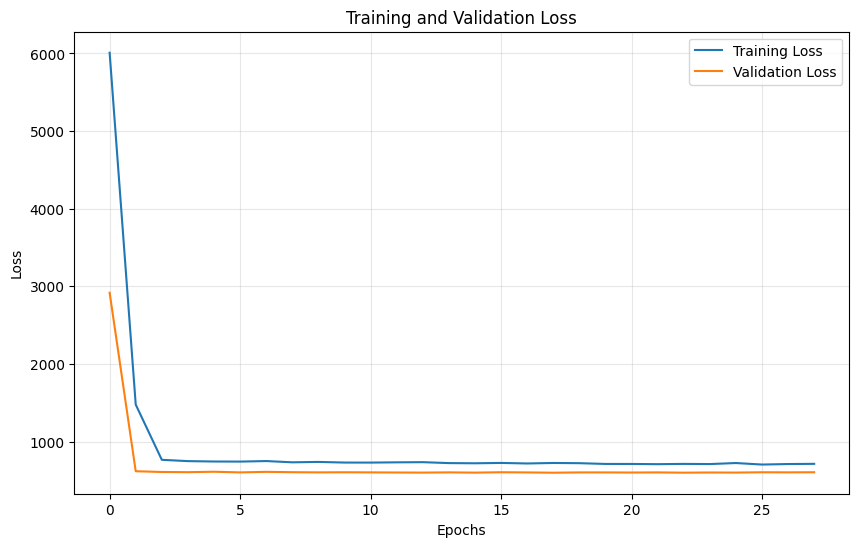

In [247]:
# Plot del grafico
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [248]:
predictions_val = model_nn.predict(X_val_pca).flatten()
predictions_test = model_nn.predict(X_test_pca).flatten()

errors_test = calculate_errors(y_test, predictions_test)
errors_val = calculate_errors(y_val, predictions_val)

print("Errore Test")
for key, value in errors_test.items():
    print(f"{key}: {value}")

print("\nErrore Val")
for key, value in errors_val.items():
    print(f"{key}: {value}")

65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
Errore Test
MSE: 313.7652893066406
RMSE: 17.713421163249087
MAE: 13.236899375915527
RRSE: 0.42625815931009436
RAE: 0.3600192541044705
R2: 0.8183040022850037
CC: 0.9087645842912357

Errore Val
MSE: 597.924560546875
RMSE: 24.45249599829995
MAE: 18.244220733642578
RRSE: 0.5852716652778086
RAE: 0.5411071963700148
R2: 0.6574570536613464
CC: 0.810936269737127


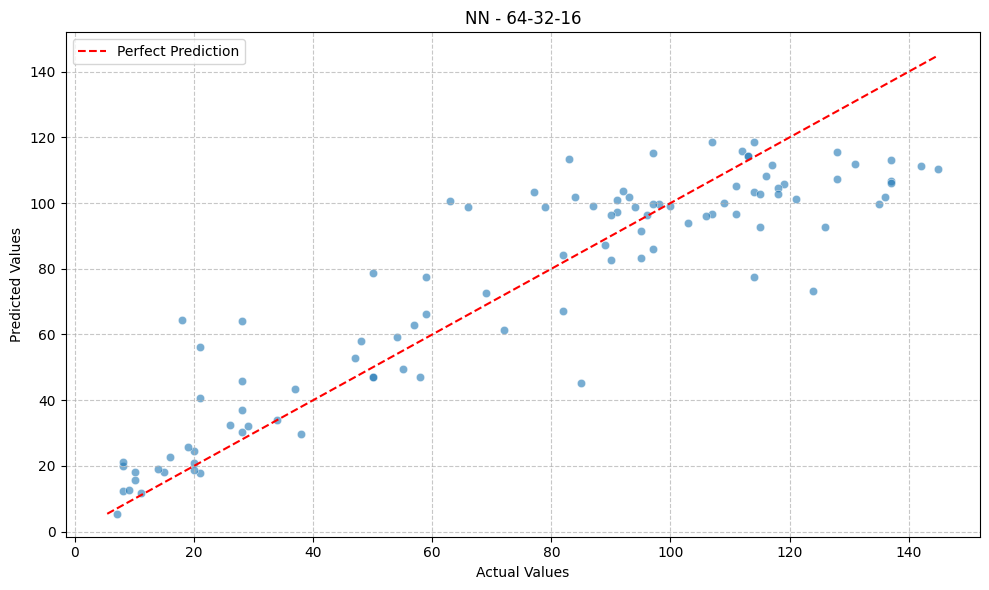

In [249]:
plot_actual_vs_predicted(y_test, predictions_test, title="NN - 64-32-16")

## 5. Cross Validation

In [250]:
from sklearn.metrics import make_scorer
from sklearn.model_selection import RepeatedKFold, cross_val_score

df_train = pd.read_csv(train_path)
df_test = pd.read_csv(test_path)

cv_strategy = RepeatedKFold(n_splits=10, n_repeats=10, random_state=42)

score_lr= cross_val_score(model_lr, X_train, y_train, cv=cv_strategy, scoring='neg_root_mean_squared_error')
score_knn = cross_val_score(model_knn, X_train, y_train, cv=cv_strategy, scoring='neg_root_mean_squared_error')

print(f"RMSE Medio LR: {-1 * np.mean(score_lr):.4f} (+/- {np.std(score_lr):.4f})\n")
print(f"RMSE Medio KNN: {-1 * np.mean(score_knn):.4f} (+/- {np.std(score_knn):.4f})\n")

RMSE Medio LR: 26.5035 (+/- 0.4798)

RMSE Medio KNN: 25.5336 (+/- 0.4840)



## 6. HyperParamater Tuning

### 6.1 KNN

  k=1: RMSE medio = 35.4277
  k=9: RMSE medio = 26.1460
  k=17: RMSE medio = 25.5336
  k=25: RMSE medio = 25.3237


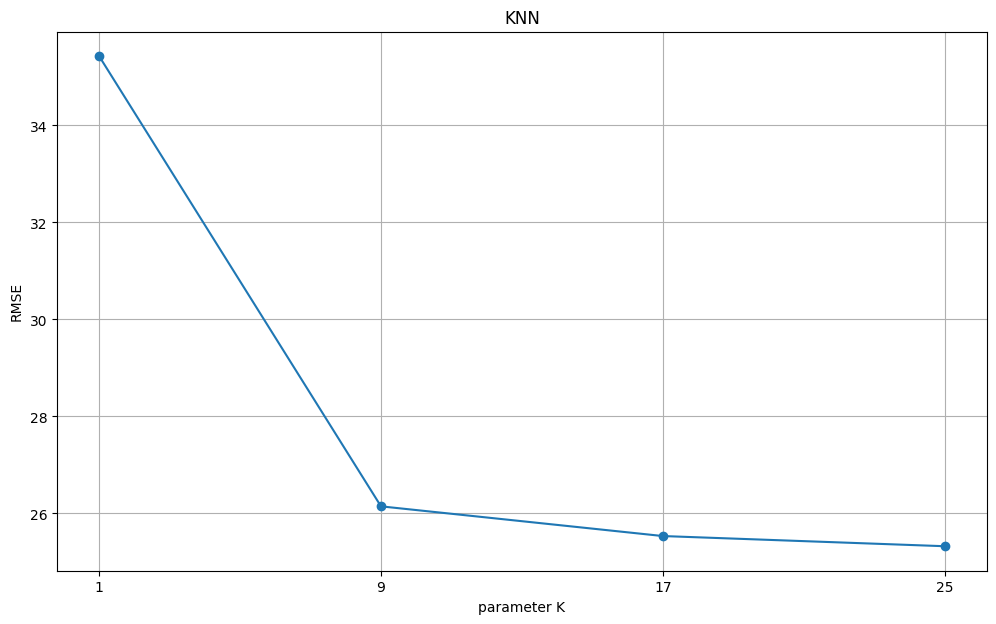

In [251]:
cv_strategy = RepeatedKFold(n_splits=10, n_repeats=10, random_state=42)


k_values = range(1, 30,8) 


avg_rmse_scores = []

for k in k_values:
    model_knn = KNeighborsRegressor(n_neighbors=k)

    neg_rmse_scores = cross_val_score(
        model_knn,
        X_train,
        y_train,
        cv=cv_strategy,
        scoring='neg_root_mean_squared_error'
    )
    
    
    rmse_scores = -neg_rmse_scores
    avg_rmse = rmse_scores.mean()
    avg_rmse_scores.append(avg_rmse)

    print(f"  k={k}: RMSE medio = {avg_rmse:.4f}")
#plot results
plt.figure(figsize=(12, 7))
plt.plot(k_values, avg_rmse_scores, marker='o', linestyle='-')

plt.title('KNN')
plt.xlabel('parameter K')
plt.ylabel('RMSE')

plt.xticks(k_values)
plt.grid(True)
plt.show()

best_k_index = np.argmin(avg_rmse_scores)
best_k = k_values[best_k_index]
min_avg_rmse = avg_rmse_scores[best_k_index]




In [252]:
print(f"\nMiglior k: {best_k}, RMSE: {min_avg_rmse:.4f}")
model_knn = KNeighborsRegressor(n_neighbors = best_k)
model_knn.fit(X_train,y_train)
prediction_test = model_knn.predict(X_test)
errors_test = calculate_errors(y_test, predictions_test)
print(errors_test)


Miglior k: 25, RMSE: 25.3237
{'MSE': 313.7652893066406, 'RMSE': np.float64(17.713421163249087), 'MAE': 13.236899375915527, 'RRSE': np.float64(0.42625815931009436), 'RAE': np.float64(0.3600192541044705), 'R2': 0.8183040022850037, 'CC': np.float64(0.9087645842912357)}


### 6.2 Random Forester

In [253]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score, root_mean_squared_error

# Definizione del modello
model_dtr = RandomForestRegressor(random_state=42)

# Definizione dei parametri da testare nella grid search
param_grid = {
    'n_estimators': [100, 200, 300],
}

# Grid Search con validazione incrociata su X_train e y_train
grid_search = GridSearchCV(estimator=model_dtr, param_grid=param_grid, 
                            scoring='neg_mean_squared_error', n_jobs=-1, verbose=1)

# Esecuzione della grid search
grid_search.fit(X_train_pca, y_train)

# Miglior modello trovato
best_model_dtr = grid_search.best_estimator_
print("Best parameters:", grid_search.best_params_)




Fitting 5 folds for each of 3 candidates, totalling 15 fits
Best parameters: {'n_estimators': 300}


In [254]:
from sklearn.metrics import mean_squared_error, r2_score, root_mean_squared_error

# Valutazione su X_val
y_val_pred = best_model_dtr.predict(X_val)
print("Validation RMSE:", root_mean_squared_error(y_val, y_val_pred))
print("Validation R²:", r2_score(y_val, y_val_pred))

# Valutazione finale su X_test
y_test_pred = best_model_dtr.predict(X_test_pca)
print("Test RMSE:", root_mean_squared_error(y_test, y_test_pred))
print("Test R²:", r2_score(y_test, y_test_pred))

Validation RMSE: 34.180507166912236
Validation R²: 0.3306925690300784
Test RMSE: 18.102074009473178
Test R²: 0.8102432960517434
